
<style>
    body {
        background-color: #0f1117;
    }

    .eda-header {
        text-align: center;
        margin: 60px 0 40px 0;
        position: relative;
    }

    .eda-header h2 {
        color: #eae4dcff;
        font-size: 36px;
        font-weight: 800;
        text-transform: uppercase;
        letter-spacing: 4px;
        margin-bottom: 10px;
    }

    .eda-header .accent-line {
        width: 100px;
        height: 4px;
        background: linear-gradient(90deg, transparent, #dcbd92ff, transparent);
        margin: 0 auto;
        border-radius: 2px;
    }

    .eda-subtitle {
        color: #f8bb38ff;
        font-size: 14px;
        font-weight: 500;
        letter-spacing: 2px;
        text-transform: uppercase;
        opacity: 0.8;
        margin-top: 12px;
    }

    .eda-card {
        background: linear-gradient(135deg, rgba(27,31,42,0.96), rgba(15,17,23,0.96));
        border: 1px solid rgba(220,189,146,0.28);
        border-radius: 18px;
        padding: 22px 26px;
        margin: 18px 0 26px 0;
        color: #eae4dcff;
        box-shadow: 0 16px 40px rgba(0,0,0,0.22);
    }

    .eda-card h3 {
        color: #dcbd92ff;
        margin-top: 0;
        font-size: 22px;
        font-weight: 700;
    }

    .eda-card p, .eda-card li {
        color: #eae4dcff;
        font-size: 15px;
        line-height: 1.75;
    }

    .eda-card strong {
        color: #f8bb38ff;
    }

    .eda-mini-title {
        color: #dcbd92ff;
        font-weight: 700;
        font-size: 18px;
        margin: 24px 0 10px 0;
        letter-spacing: 1px;
        text-transform: uppercase;
    }
</style>

<div class="eda-header">
    <h2>Bank Customer Churn Prediction</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Complete notebook — EDA, Feature Engineering, 5 models, tuning and final evaluation</div>
</div>



<div class="eda-card">
<h3>Objectif du projet</h3>

<p>Ce notebook a pour objectif de construire un modèle de prédiction du churn bancaire à partir du dataset <strong>Churn_Modelling.csv</strong>.</p>
<ul>
<li>Comprendre la structure des données.</li>
<li>Réaliser une analyse exploratoire cohérente.</li>
<li>Justifier le Feature Engineering à partir des observations EDA.</li>
<li>Comparer uniquement les 5 algorithmes imposés : <strong>Logistic Regression, KNN, Decision Tree, Random Forest, SVC</strong>.</li>
<li>Sauvegarder les modèles entraînés pour une future intégration Streamlit.</li>
</ul>

</div>



<div class="eda-header">
    <h2>1. Imports and Configuration</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Libraries, display settings and global constants</div>
</div>


In [1]:

# ============================================================
# 1) Imports and global configuration
# ============================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.base import clone

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20

# Visual theme for plots
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor": "#1b1f2a",
    "axes.edgecolor": "#dcbd92",
    "axes.labelcolor": "#eae4dc",
    "xtick.color": "#eae4dc",
    "ytick.color": "#eae4dc",
    "text.color": "#eae4dc",
    "axes.titlecolor": "#f8bb38",
    "grid.color": "#3a3f4b",
    "legend.facecolor": "#1b1f2a",
    "legend.edgecolor": "#dcbd92",
    "legend.labelcolor": "#eae4dc",
    "font.size": 11
})

sns.set_palette(["#dcbd92", "#f8bb38", "#eae4dc", "#8c7a5f", "#c2a674"])

print("Configuration completed successfully.")


Configuration completed successfully.



<div class="eda-header">
    <h2>2. Data Loading</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Read the churn dataset and inspect the first rows</div>
</div>


In [2]:

# ============================================================
# 2) Load dataset
# ============================================================

DATA_PATH = "Churn_Modelling.csv"

# Compatibility if the notebook is executed inside another environment
if not os.path.exists(DATA_PATH):
    alt_path = "/mnt/data/Churn_Modelling.csv"
    if os.path.exists(alt_path):
        DATA_PATH = alt_path

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "Churn_Modelling.csv not found. Please place the file in the same folder as this notebook."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())


Dataset loaded successfully.
Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



<div class="eda-header">
    <h2>3. Data Understanding</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Structure, data types, missing values and duplicated rows</div>
</div>


In [3]:

# ============================================================
# 3) Basic data understanding
# ============================================================

print("Dataset shape:", df.shape)
print(); print("Columns:")
print(df.columns.tolist())

print(); print("Data types:")
display(df.dtypes.to_frame("dtype"))

print(); print("Missing values:")
missing_df = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})
display(missing_df)

print(); print("Duplicated rows:", df.duplicated().sum())

print(); print("Statistical summary:")
display(df.describe().T)


Dataset shape: (10000, 14)

Columns:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data types:


,dtype
RowNumber,int64
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Gender,object
Age,int64
Tenure,int64
Balance,float64
NumOfProducts,int64



Missing values:


,missing_count,missing_percent
RowNumber,0,0.0
CustomerId,0,0.0
Surname,0,0.0
CreditScore,0,0.0
Geography,0,0.0
Gender,0,0.0
Age,0,0.0
Tenure,0,0.0
Balance,0,0.0
NumOfProducts,0,0.0



Duplicated rows: 0

Statistical summary:


,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48



<div class="eda-header">
    <h2>4. Analyse Exploratoire des Données</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">EDA aligned with the future Feature Engineering</div>
</div>



<div class="eda-card">
<h3>Logique de cette partie</h3>

<p>Cette partie EDA n'est pas seulement descriptive. Elle sert à comprendre les variables qui influencent le churn et à préparer le <strong>Feature Engineering</strong>.</p>
<p>Chaque observation importante sera ensuite transformée en une variable explicative utile pour les modèles.</p>

</div>


,Class,Count,Percentage
0,Not Exited,7963,79.63
1,Exited,2037,20.37


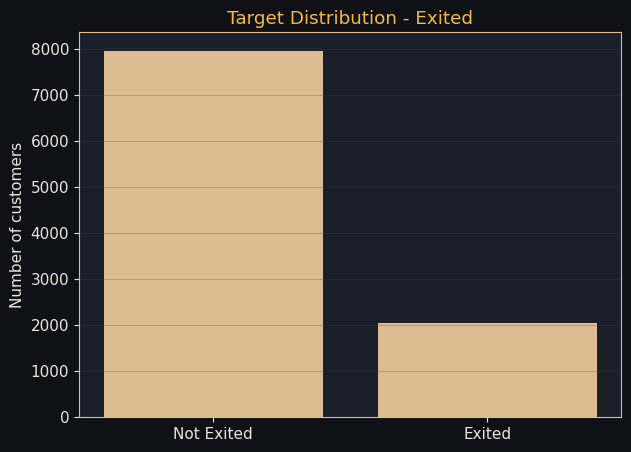

In [4]:

# ============================================================
# 4.1 Target distribution
# ============================================================

target_counts = df["Exited"].value_counts().sort_index()
target_percent = (df["Exited"].value_counts(normalize=True).sort_index() * 100).round(2)

target_summary = pd.DataFrame({
    "Class": ["Not Exited", "Exited"],
    "Count": target_counts.values,
    "Percentage": target_percent.values
})

display(target_summary)

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(["Not Exited", "Exited"], target_counts.values)
ax.set_title("Target Distribution - Exited")
ax.set_ylabel("Number of customers")
ax.grid(axis="y", alpha=0.25)
plt.show()



<div class="eda-card">
<h3>Observation EDA — Target imbalance</h3>

<p>La variable cible <strong>Exited</strong> est déséquilibrée : la majorité des clients ne quittent pas la banque.</p>
<p>Conséquence directe : l'<strong>accuracy</strong> seule ne suffit pas. Dans l'évaluation finale, on utilisera aussi <strong>Recall, F1-score, Balanced Accuracy et ROC-AUC</strong>.</p>

</div>


In [5]:

# ============================================================
# 4.2 Helper functions for EDA
# ============================================================

def churn_rate_table(data, column):
    table = (
        data.groupby(column)["Exited"]
        .agg(Count="count", Churn_Rate="mean")
        .reset_index()
        .sort_values("Churn_Rate", ascending=False)
    )
    table["Churn_Rate_%"] = (table["Churn_Rate"] * 100).round(2)
    return table


def plot_churn_rate(data, column, title=None, rotate=0):
    table = churn_rate_table(data, column)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(table[column].astype(str), table["Churn_Rate_%"])
    ax.set_title(title or f"Churn Rate by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Churn Rate (%)")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=rotate)
    plt.show()
    display(table)



<div class="eda-header">
    <h2>4.1 Categorical Analysis</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Geography, Gender, Products, Credit Card and Activity</div>
</div>


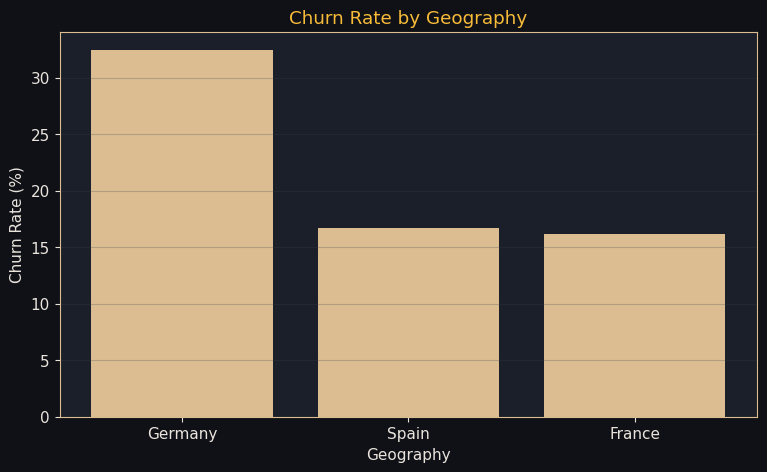

,Geography,Count,Churn_Rate,Churn_Rate_%
1,Germany,2509,0.324432,32.44
2,Spain,2477,0.166734,16.67
0,France,5014,0.161548,16.15


In [6]:

# Geography vs churn
plot_churn_rate(df, "Geography", "Churn Rate by Geography")



<div class="eda-card">
<h3>Observation — Geography</h3>

<p>Les clients en <strong>Germany</strong> présentent généralement un taux de churn plus élevé que les autres pays.</p>
<p>Cette observation justifie la création d'une variable d'interaction <strong>Germany_Age</strong>, car l'effet du pays peut être renforcé par l'âge.</p>

</div>


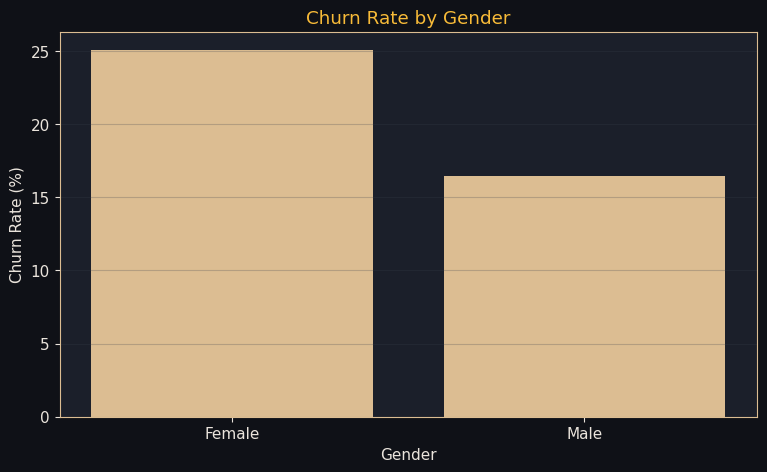

,Gender,Count,Churn_Rate,Churn_Rate_%
0,Female,4543,0.250715,25.07
1,Male,5457,0.164559,16.46


In [7]:

# Gender vs churn
plot_churn_rate(df, "Gender", "Churn Rate by Gender")


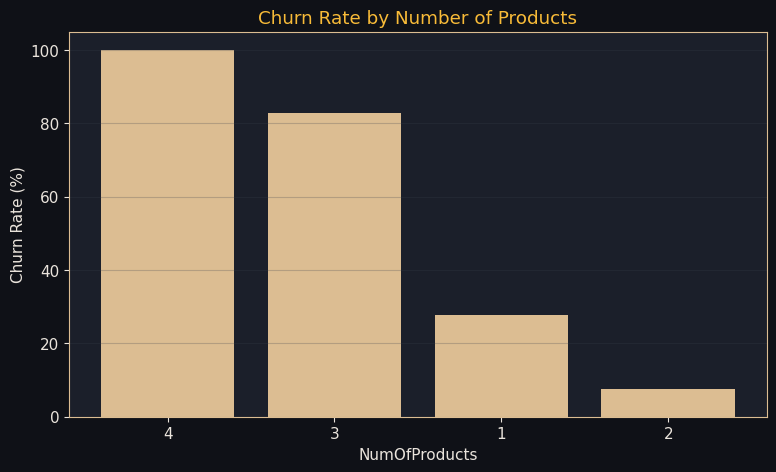

,NumOfProducts,Count,Churn_Rate,Churn_Rate_%
3,4,60,1.000000,100.00
2,3,266,0.827068,82.71
0,1,5084,0.277144,27.71
1,2,4590,0.075817,7.58


In [8]:

# NumOfProducts vs churn
plot_churn_rate(df, "NumOfProducts", "Churn Rate by Number of Products")



<div class="eda-card">
<h3>Observation — NumOfProducts</h3>

<p>Les clients ayant <strong>3 ou 4 produits</strong> ont un comportement très différent et un taux de churn très élevé.</p>
<p>Cette observation justifie la création de la variable <strong>ThreePlusProducts</strong>.</p>

</div>


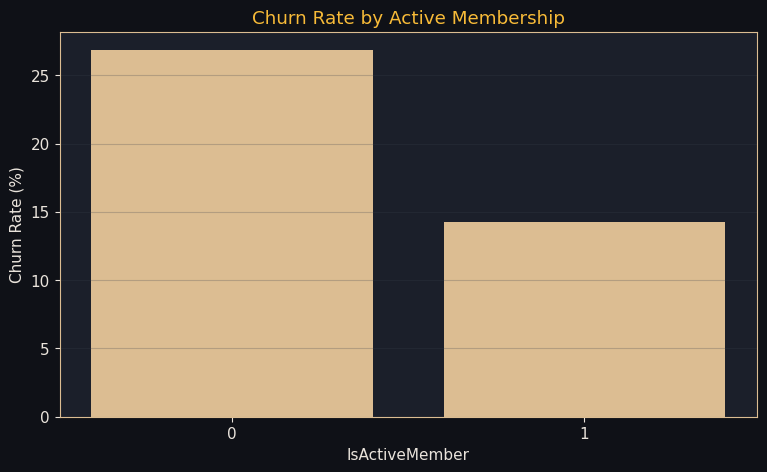

,IsActiveMember,Count,Churn_Rate,Churn_Rate_%
0,0,4849,0.268509,26.85
1,1,5151,0.142691,14.27


In [9]:

# IsActiveMember vs churn
plot_churn_rate(df, "IsActiveMember", "Churn Rate by Active Membership")



<div class="eda-card">
<h3>Observation — Activity</h3>

<p>Les clients inactifs quittent plus souvent la banque que les clients actifs.</p>
<p>L'activité du client devient encore plus intéressante lorsqu'elle est combinée avec l'âge. Cela justifie la variable <strong>Age_IsActive</strong>.</p>

</div>


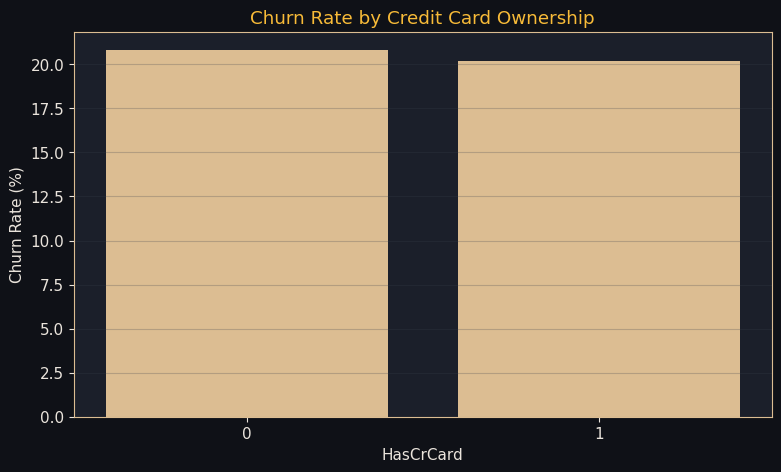

,HasCrCard,Count,Churn_Rate,Churn_Rate_%
0,0,2945,0.208149,20.81
1,1,7055,0.201843,20.18


In [10]:

# HasCrCard vs churn
plot_churn_rate(df, "HasCrCard", "Churn Rate by Credit Card Ownership")



<div class="eda-header">
    <h2>4.2 Numerical Analysis</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Age, Balance, Salary and Credit Score</div>
</div>


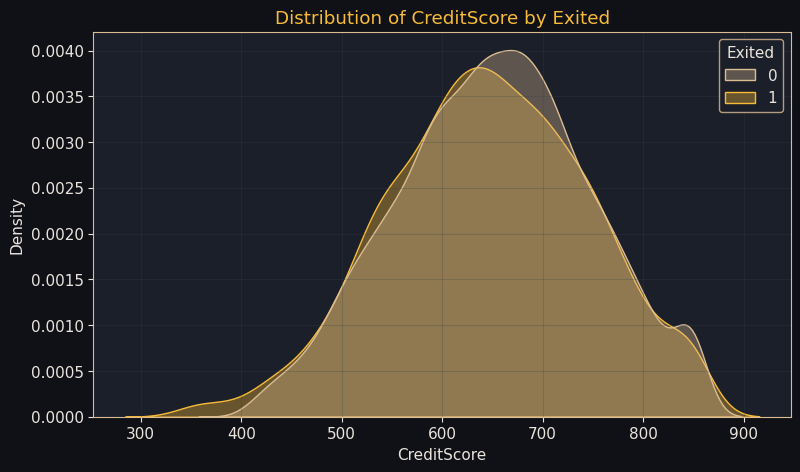

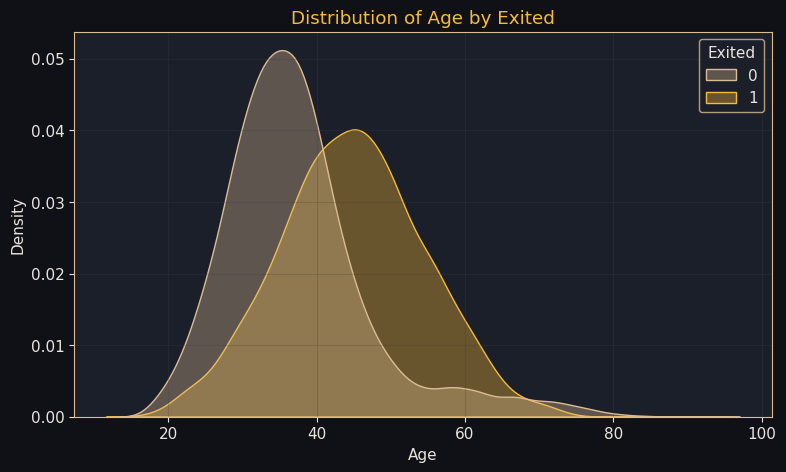

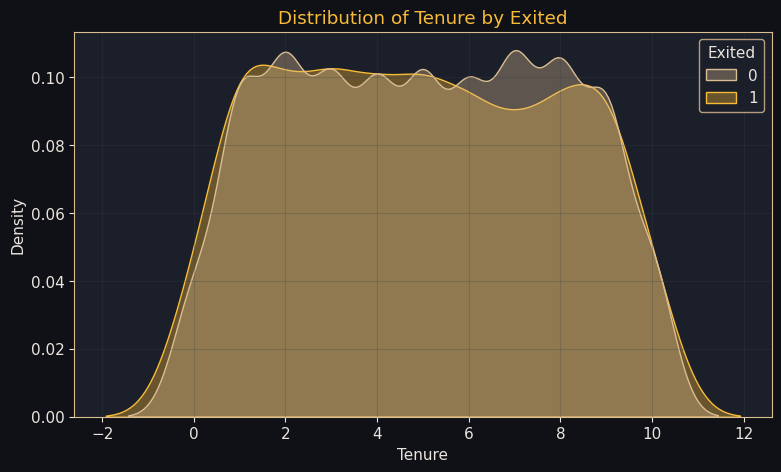

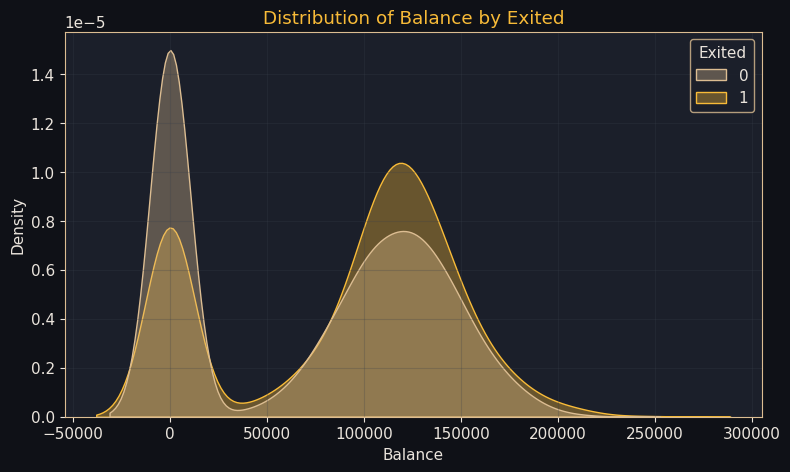

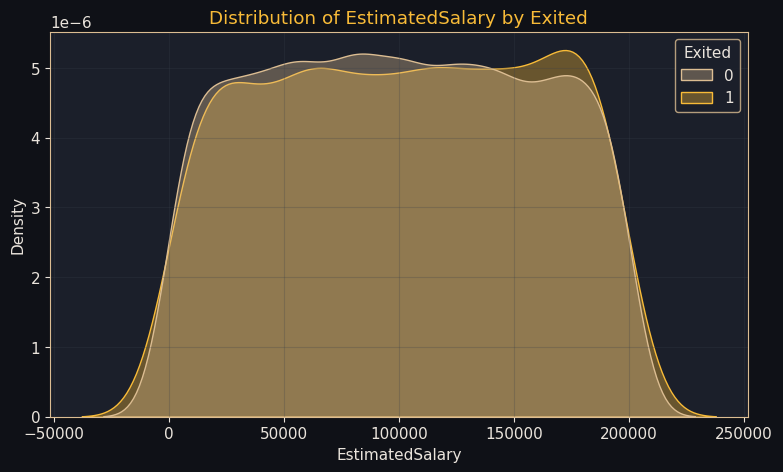

In [11]:

# Numerical distributions by target
numeric_cols = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]

for col in numeric_cols:
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.kdeplot(data=df, x=col, hue="Exited", fill=True, common_norm=False, alpha=0.35, ax=ax)
    ax.set_title(f"Distribution of {col} by Exited")
    ax.grid(alpha=0.25)
    plt.show()


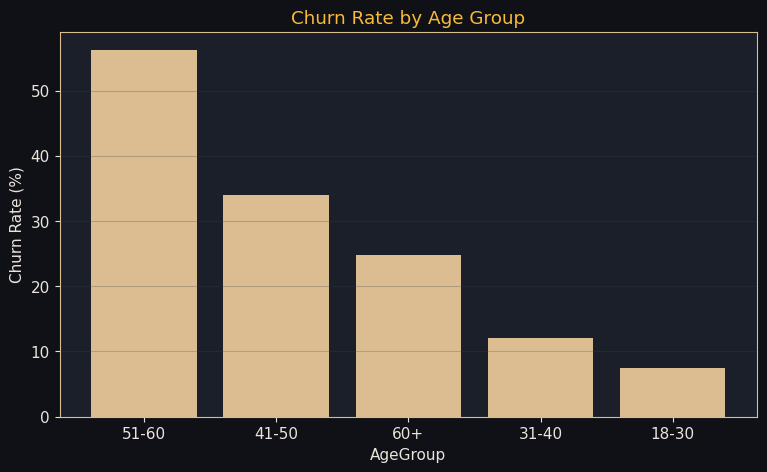

,AgeGroup,Count,Churn_Rate,Churn_Rate_%
3,51-60,797,0.562108,56.21
2,41-50,2320,0.339655,33.97
4,60+,464,0.247845,24.78
1,31-40,4451,0.120872,12.09
0,18-30,1968,0.075203,7.52


In [12]:

# Age groups vs churn
age_bins = [17, 30, 40, 50, 60, 100]
age_labels = ["18-30", "31-40", "41-50", "51-60", "60+"]

df_eda = df.copy()
df_eda["AgeGroup"] = pd.cut(
    df_eda["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

plot_churn_rate(df_eda, "AgeGroup", "Churn Rate by Age Group")



<div class="eda-card">
<h3>Observation — Age</h3>

<p>L'âge est l'une des variables les plus importantes. Les clients plus âgés, surtout certaines tranches, présentent un risque de churn plus élevé.</p>
<p>Cette observation justifie deux variables :</p>
<ul>
<li><strong>AgeGroup</strong> : transformation de l'âge en catégories interprétables.</li>
<li><strong>Age_NumProducts</strong> : interaction entre l'âge et le nombre de produits.</li>
</ul>

</div>


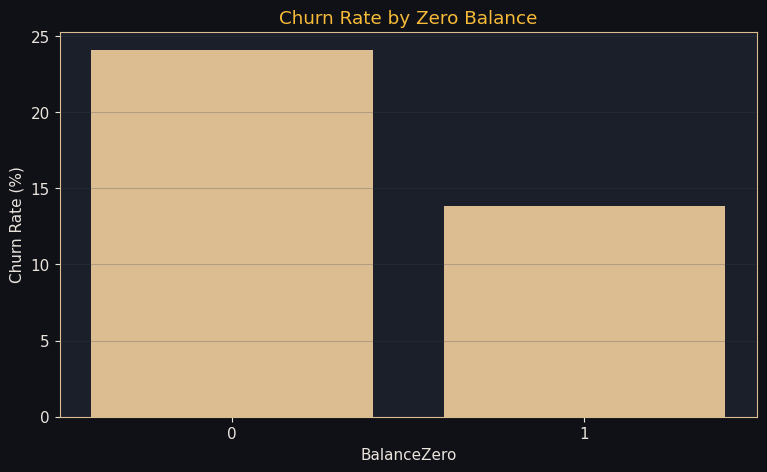

,BalanceZero,Count,Churn_Rate,Churn_Rate_%
0,0,6383,0.240796,24.08
1,1,3617,0.138236,13.82


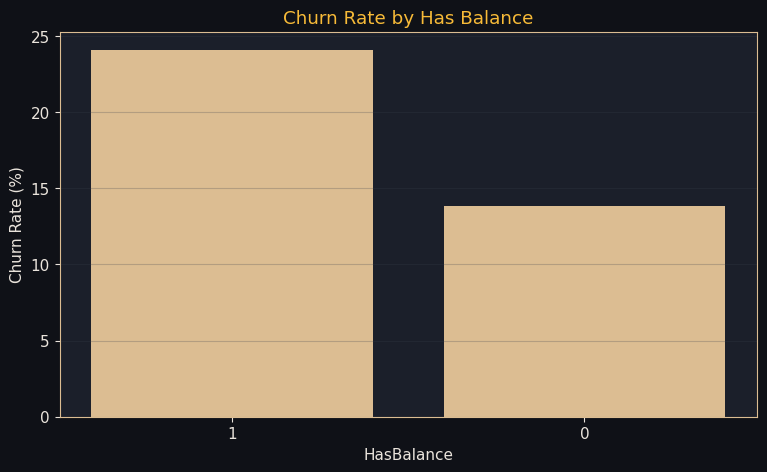

,HasBalance,Count,Churn_Rate,Churn_Rate_%
1,1,6383,0.240796,24.08
0,0,3617,0.138236,13.82


In [13]:

# BalanceZero / HasBalance analysis

df_eda["BalanceZero"] = (df_eda["Balance"] == 0).astype(int)
df_eda["HasBalance"] = (df_eda["Balance"] > 0).astype(int)

plot_churn_rate(df_eda, "BalanceZero", "Churn Rate by Zero Balance")
plot_churn_rate(df_eda, "HasBalance", "Churn Rate by Has Balance")



<div class="eda-card">
<h3>Observation — Balance</h3>

<p>Le comportement des clients avec un solde nul est différent de celui des clients ayant un solde positif.</p>
<p>Cette observation justifie la création de <strong>BalanceZero</strong> et <strong>HasBalance</strong>.</p>

</div>


,BalanceSalaryRatioGroup,Count,Churn_Rate,Churn_Rate_%
3,"(1.887, 9770.883]",2000,0.24800,24.80
1,"(0.531, 0.946]",2000,0.24500,24.50
2,"(0.946, 1.887]",2000,0.23200,23.20
0,"(-0.001, 0.531]",4000,0.14675,14.68


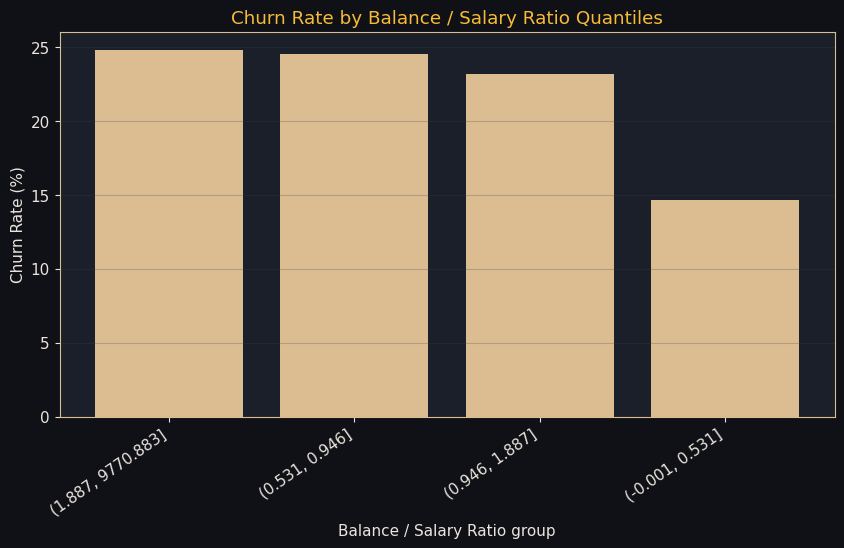

In [14]:

# Balance to salary ratio analysis

df_eda["BalanceSalaryRatio"] = df_eda["Balance"] / (df_eda["EstimatedSalary"] + 1)

df_eda["BalanceSalaryRatioGroup"] = pd.qcut(
    df_eda["BalanceSalaryRatio"],
    q=5,
    duplicates="drop"
)

ratio_table = churn_rate_table(df_eda, "BalanceSalaryRatioGroup")
display(ratio_table)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ratio_table["BalanceSalaryRatioGroup"].astype(str), ratio_table["Churn_Rate_%"])
ax.set_title("Churn Rate by Balance / Salary Ratio Quantiles")
ax.set_xlabel("Balance / Salary Ratio group")
ax.set_ylabel("Churn Rate (%)")
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=35, ha="right")
plt.show()



<div class="eda-card">
<h3>Observation — BalanceSalaryRatio</h3>

<p>Le solde seul ne donne pas toute l'information. Le rapport entre le solde et le salaire estimé permet de mieux représenter le poids financier du solde pour chaque client.</p>
<p>Cette observation justifie la création de <strong>BalanceSalaryRatio</strong>.</p>

</div>


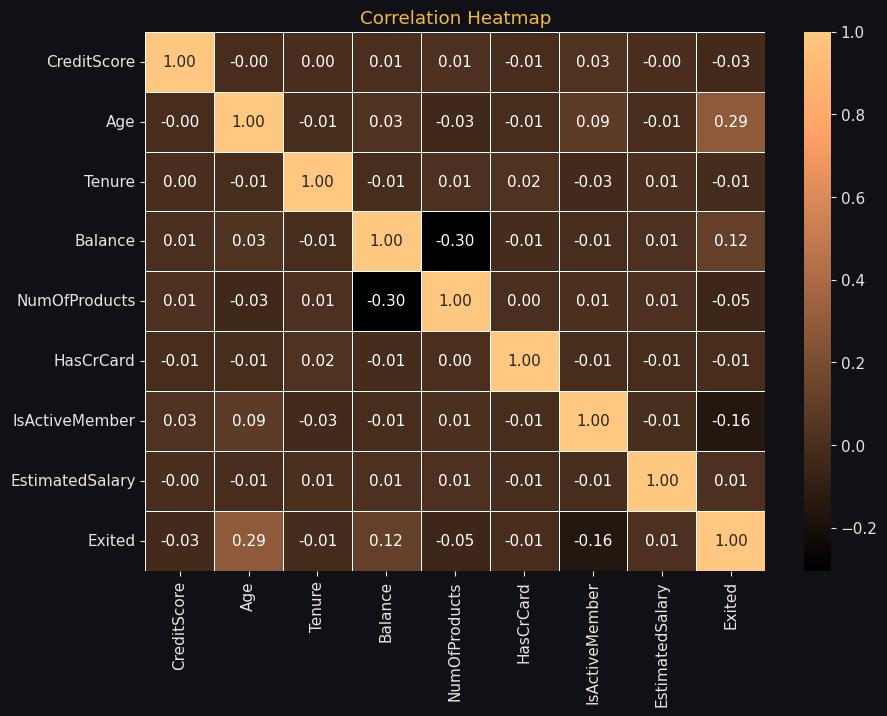

In [15]:

# Correlation heatmap on numerical variables
corr_cols = [
    "CreditScore", "Age", "Tenure", "Balance", "NumOfProducts",
    "HasCrCard", "IsActiveMember", "EstimatedSalary", "Exited"
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="copper", linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap")
plt.show()



<div class="eda-header">
    <h2>4.3 EDA to Feature Engineering Mapping</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Every engineered feature is justified by the EDA</div>
</div>


In [16]:

# ============================================================
# 4.3 EDA findings mapped to Feature Engineering decisions
# ============================================================

eda_to_fe = pd.DataFrame({
    "EDA observation": [
        "Customers with zero balance behave differently from customers with positive balance.",
        "Balance alone is less informative than balance compared to estimated salary.",
        "Age has a strong relationship with churn.",
        "Customer activity impacts churn and interacts with age.",
        "Number of products has a non-linear impact; 3+ products are high-risk.",
        "Germany has a higher churn rate than other countries.",
        "Age groups show different churn patterns."
    ],
    "Feature created": [
        "BalanceZero, HasBalance",
        "BalanceSalaryRatio",
        "AgeGroup",
        "Age_IsActive",
        "ThreePlusProducts, Age_NumProducts",
        "Germany_Age",
        "AgeGroup"
    ],
    "Expected benefit": [
        "Capture the special behavior of customers with no balance.",
        "Normalize balance according to customer's income level.",
        "Capture non-linear age effects.",
        "Represent combined effect of age and activity.",
        "Capture non-linear product risk.",
        "Capture interaction between geography and age.",
        "Make age more interpretable for models."
    ]
})

display(eda_to_fe)


,EDA observation,Feature created,Expected benefit
0,Customers with zero balance behave differently...,"BalanceZero, HasBalance",Capture the special behavior of customers with...
1,Balance alone is less informative than balance...,BalanceSalaryRatio,Normalize balance according to customer's inco...
2,Age has a strong relationship with churn.,AgeGroup,Capture non-linear age effects.
3,Customer activity impacts churn and interacts ...,Age_IsActive,Represent combined effect of age and activity.
4,Number of products has a non-linear impact; 3+...,"ThreePlusProducts, Age_NumProducts",Capture non-linear product risk.
5,Germany has a higher churn rate than other cou...,Germany_Age,Capture interaction between geography and age.
6,Age groups show different churn patterns.,AgeGroup,Make age more interpretable for models.



<div class="eda-header">
    <h2>5. Feature Engineering</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Create robust features based on EDA observations</div>
</div>


In [17]:

# ============================================================
# 5) Feature engineering function
# ============================================================

def add_churn_features(X):
    """
    Add new features based only on input X.

    Important:
    - This function does not use y.
    - This function does not learn from the full dataset.
    - It can be safely used inside a sklearn Pipeline through FunctionTransformer.
    """

    X = X.copy()

    # Balance behavior
    X["BalanceZero"] = (X["Balance"] == 0).astype(int)
    X["HasBalance"] = (X["Balance"] > 0).astype(int)
    X["BalanceSalaryRatio"] = X["Balance"] / (X["EstimatedSalary"] + 1)

    # Interaction features
    X["Age_IsActive"] = X["Age"] * X["IsActiveMember"]
    X["Age_NumProducts"] = X["Age"] * X["NumOfProducts"]
    X["Germany_Age"] = (X["Geography"].eq("Germany").astype(int)) * X["Age"]

    # Non-linear product behavior
    X["ThreePlusProducts"] = (X["NumOfProducts"] >= 3).astype(int)

    # Age categories
    X["AgeGroup"] = pd.cut(
        X["Age"],
        bins=[17, 30, 40, 50, 60, 100],
        labels=["18-30", "31-40", "41-50", "51-60", "60+"],
        include_lowest=True
    ).astype("object")

    return X

print("Feature engineering function created successfully.")


Feature engineering function created successfully.


In [18]:

# Preview engineered features
preview_cols = [
    "Age", "Geography", "Balance", "EstimatedSalary", "NumOfProducts", "IsActiveMember"
]

engineered_preview = add_churn_features(df[preview_cols + ["CreditScore", "Gender", "Tenure", "HasCrCard"]].copy())

new_features = [
    "BalanceZero", "HasBalance", "BalanceSalaryRatio", "Age_IsActive",
    "Age_NumProducts", "Germany_Age", "ThreePlusProducts", "AgeGroup"
]

display(engineered_preview[preview_cols + new_features].head())


,Age,Geography,Balance,EstimatedSalary,NumOfProducts,IsActiveMember,BalanceZero,HasBalance,BalanceSalaryRatio,Age_IsActive,Age_NumProducts,Germany_Age,ThreePlusProducts,AgeGroup
0,42,France,0.00,101348.88,1,1,1,0,0.000000,42,42,0,0,41-50
1,41,Spain,83807.86,112542.58,1,1,0,1,0.744670,41,41,0,0,41-50
2,42,France,159660.80,113931.57,3,0,0,1,1.401362,0,126,0,1,41-50
3,39,France,0.00,93826.63,2,0,1,0,0.000000,0,78,0,0,31-40
4,43,Spain,125510.82,79084.10,1,1,0,1,1.587035,43,43,0,0,41-50



<div class="eda-header">
    <h2>6. Data Preparation</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Drop identifiers and split data correctly</div>
</div>


In [19]:

# ============================================================
# 6) Data preparation
# ============================================================

# These columns are identifiers and must not be used for modeling
id_columns = ["RowNumber", "CustomerId", "Surname"]

df_model = df.drop(columns=id_columns)

X = df_model.drop(columns=["Exited"])
y = df_model["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True).round(4))
print(); print("y_test distribution:")
print(y_test.value_counts(normalize=True).round(4))


X_train: (8000, 10)
X_test: (2000, 10)
y_train distribution:
Exited
0    0.7962
1    0.2037
Name: proportion, dtype: float64

y_test distribution:
Exited
0    0.7965
1    0.2035
Name: proportion, dtype: float64



<div class="eda-card">
<h3>Important — Avoiding data leakage</h3>

<p>Le split est réalisé avant le preprocessing avancé. Le scaler, l'imputer, l'encoder et les transformations sont placés dans des pipelines sklearn.</p>
<p>Cela évite le <strong>data leakage</strong>, car les transformations apprennent uniquement sur le training set.</p>

</div>



<div class="eda-header">
    <h2>7. Preprocessing Pipelines</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Separate preprocessing for scaled models and tree-based models</div>
</div>


In [20]:

# ============================================================
# 7) Preprocessing pipelines
# ============================================================

# sklearn compatibility for OneHotEncoder
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

feature_engineer = FunctionTransformer(add_churn_features, validate=False)

# Apply FE only on training sample to detect resulting columns
X_tmp = add_churn_features(X_train.copy())

numeric_features = X_tmp.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X_tmp.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print(numeric_features)
print(); print("Number of categorical features:", len(categorical_features))
print(categorical_features)

numeric_scaled_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_tree_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", ohe)
])

# Logistic Regression, KNN, SVC need/recommend scaling
preprocess_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_scaled_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

# Decision Tree and Random Forest do not need scaling
preprocess_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_tree_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipelines created successfully.")


Number of numeric features: 15
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceZero', 'HasBalance', 'BalanceSalaryRatio', 'Age_IsActive', 'Age_NumProducts', 'Germany_Age', 'ThreePlusProducts']

Number of categorical features: 3
['Geography', 'Gender', 'AgeGroup']
Preprocessing pipelines created successfully.



<div class="eda-header">
    <h2>8. Baseline Models</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Train the five required algorithms before tuning</div>
</div>


In [21]:

# ============================================================
# 8) Helper scoring function
# ============================================================

def get_prediction_scores(model, X_data):
    """Return probability scores or decision scores for ROC-AUC."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_data)
    return None


def get_scores(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_score = get_prediction_scores(model, X_test)

    scores = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Precision_churn": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "Recall_churn": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "F1_churn": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
    }

    if y_score is not None:
        scores["AUC"] = roc_auc_score(y_test, y_score)
    else:
        scores["AUC"] = np.nan

    return scores


In [22]:

# ============================================================
# 8.1 Train baseline models
# ============================================================

baseline_models = {
    "Logistic Regression": Pipeline([
        ("features", feature_engineer),
        ("prep", preprocess_scaled),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
    ]),

    "KNN": Pipeline([
        ("features", feature_engineer),
        ("prep", preprocess_scaled),
        ("model", KNeighborsClassifier())
    ]),

    "Decision Tree": Pipeline([
        ("features", feature_engineer),
        ("prep", preprocess_tree),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),

    "Random Forest": Pipeline([
        ("features", feature_engineer),
        ("prep", preprocess_tree),
        ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))
    ]),

    "SVC": Pipeline([
        ("features", feature_engineer),
        ("prep", preprocess_scaled),
        ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE, cache_size=1000))
    ])
}

baseline_results = []

for name, model in baseline_models.items():
    print("Training baseline:", name)
    model.fit(X_train, y_train)
    scores = get_scores(model, X_test, y_test)
    baseline_results.append({"Model": name, **scores})

baseline_results_df = pd.DataFrame(baseline_results).sort_values("Accuracy", ascending=False)

display(
    baseline_results_df.style.format({
        "Accuracy": "{:.4f}",
        "Balanced_Accuracy": "{:.4f}",
        "Precision_macro": "{:.4f}",
        "Recall_macro": "{:.4f}",
        "F1_macro": "{:.4f}",
        "Precision_churn": "{:.4f}",
        "Recall_churn": "{:.4f}",
        "F1_churn": "{:.4f}",
        "AUC": "{:.4f}"
    })
)


Training baseline: Logistic Regression
Training baseline: KNN
Training baseline: Decision Tree
Training baseline: Random Forest
Training baseline: SVC


,Model,Accuracy,Balanced_Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_churn,Recall_churn,F1_churn,AUC
0,Logistic Regression,0.8625,0.7061,0.8307,0.7061,0.7426,0.7895,0.4423,0.5669,0.8502
4,SVC,0.8620,0.7021,0.8333,0.7021,0.7393,0.7964,0.4324,0.5605,0.8213
3,Random Forest,0.8550,0.7078,0.8007,0.7078,0.7382,0.7276,0.4595,0.5633,0.8463
1,KNN,0.8410,0.6926,0.7665,0.6926,0.7176,0.6642,0.4423,0.5310,0.7790
2,Decision Tree,0.7870,0.6916,0.6778,0.6916,0.6840,0.4789,0.5307,0.5035,0.6916



<div class="eda-header">
    <h2>9. Hyperparameter Tuning</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">RandomizedSearchCV on only the five required algorithms</div>
</div>


In [ ]:

# ============================================================
# 9a) Hyperparameter tuning — uniquement les 5 algorithmes
# ============================================================

os.makedirs("saved_models", exist_ok=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Increase to 30 or 50 if your PC supports it
N_ITER = 25

search_models = {
    "Logistic Regression": Pipeline([
        ("features", feature_engineer),
        ("prep", preprocess_scaled),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
    ]),

    "KNN": Pipeline([
        ("features", feature_engineer),
        ("prep", preprocess_scaled),
        ("model", KNeighborsClassifier())
    ]),

    "Decision Tree": Pipeline([
        ("features", feature_engineer),
        ("prep", preprocess_tree),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),

    "Random Forest": Pipeline([
        ("features", feature_engineer),
        ("prep", preprocess_tree),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
    ]),

    "SVC": Pipeline([
        ("features", feature_engineer),
        ("prep", preprocess_scaled),
        ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE, cache_size=1000))
    ])
}

param_spaces = {
    "Logistic Regression": {
        "model__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20],
        "model__class_weight": [None, "balanced"],
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15, 17, 21, 25, 31, 41],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    },

    "Decision Tree": {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [3, 4, 5, 6, 8, 10, 12, None],
        "model__min_samples_split": [2, 5, 10, 20, 40, 60],
        "model__min_samples_leaf": [1, 2, 5, 10, 20, 40],
        "model__class_weight": [None, "balanced"]
    },

    "Random Forest": {
        "model__n_estimators": [200, 300, 400, 500, 700],
        "model__max_depth": [6, 8, 10, 12, 15, 20, None],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 3, 4, 6, 8],
        "model__max_features": ["sqrt", "log2", 0.5],
        "model__bootstrap": [True],
        "model__class_weight": [None, "balanced"]
    },

    "SVC": {
        "model__C": [0.5, 1, 2, 3, 5, 10, 20],
        "model__gamma": ["scale", 0.005, 0.01, 0.03, 0.05, 0.1],
        "model__class_weight": [None, "balanced"]
    }
}

searches = {}
tuned_models = {}
tuned_results = []

for name in search_models.keys():
    print(); print("=" * 80)
    print("Tuning:", name)

    search = RandomizedSearchCV(
        estimator=search_models[name],
        param_distributions=param_spaces[name],
        n_iter=N_ITER,
        scoring="accuracy",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    search.fit(X_train, y_train)

    searches[name] = search
    best_model = search.best_estimator_
    tuned_models[name] = best_model

    scores = get_scores(best_model, X_test, y_test)

    tuned_results.append({
        "Model": name,
        "Best_CV_Accuracy": search.best_score_,
        **scores,
        "Best_Params": search.best_params_
    })

    # Save each tuned model
    model_file_name = name.lower().replace(" ", "_") + "_tuned.pkl"
    model_path = os.path.join("saved_models", model_file_name)
    joblib.dump(best_model, model_path)

    print("Best CV Accuracy:", round(search.best_score_, 4))
    print("Test Accuracy:", round(scores["Accuracy"], 4))
    print("Model saved in:", model_path)
    print("Best params:", search.best_params_)

# Results dataframe
tuned_results_df = pd.DataFrame(tuned_results).sort_values("Accuracy", ascending=False)

display(
    tuned_results_df[
        [
            "Model", "Best_CV_Accuracy", "Accuracy", "Balanced_Accuracy",
            "Precision_macro", "Recall_macro", "F1_macro",
            "Precision_churn", "Recall_churn", "F1_churn", "AUC"
        ]
    ].style.format({
        "Best_CV_Accuracy": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Balanced_Accuracy": "{:.4f}",
        "Precision_macro": "{:.4f}",
        "Recall_macro": "{:.4f}",
        "F1_macro": "{:.4f}",
        "Precision_churn": "{:.4f}",
        "Recall_churn": "{:.4f}",
        "F1_churn": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

# Save results table
tuned_results_df.to_csv("saved_models/tuned_results.csv", index=False)

# Save best overall model based on test accuracy
best_model_name = tuned_results_df.iloc[0]["Model"]
best_model = tuned_models[best_model_name]
joblib.dump(best_model, "saved_models/best_churn_model.pkl")

print(); print("Best overall model:", best_model_name)
print("Best test accuracy:", round(tuned_results_df.iloc[0]["Accuracy"], 4))
print("Best model saved in: saved_models/best_churn_model.pkl")

# Update models dictionary for the next evaluation sections
models = tuned_models



Tuning: Logistic Regression
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV Accuracy: 0.852
Test Accuracy: 0.863
Model saved in: saved_models\logistic_regression_tuned.pkl
Best params: {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__class_weight': None, 'model__C': 2}

Tuning: KNN
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV Accuracy: 0.857
Test Accuracy: 0.865
Model saved in: saved_models\knn_tuned.pkl
Best params: {'model__weights': 'distance', 'model__p': 1, 'model__n_neighbors': 41}

Tuning: Decision Tree
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV Accuracy: 0.854
Test Accuracy: 0.8605
Model saved in: saved_models\decision_tree_tuned.pkl
Best params: {'model__min_samples_split': 2, 'model__min_samples_leaf': 40, 'model__max_depth': 8, 'model__criterion': 'gini', 'model__class_weight': None}

Tuning: Random Forest
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV Accuracy: 0.8634

,Model,Best_CV_Accuracy,Accuracy,Balanced_Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_churn,Recall_churn,F1_churn,AUC
1,KNN,0.8570,0.8650,0.7049,0.8433,0.7049,0.7437,0.8157,0.4349,0.5673,0.8578
3,Random Forest,0.8634,0.8635,0.7012,0.8413,0.7012,0.7398,0.8131,0.4275,0.5604,0.8661
0,Logistic Regression,0.8520,0.8630,0.7073,0.8314,0.7073,0.7439,0.7904,0.4447,0.5692,0.8501
4,SVC,0.8575,0.8620,0.7048,0.8300,0.7048,0.7413,0.7885,0.4398,0.5647,0.8173
2,Decision Tree,0.8540,0.8605,0.7185,0.8111,0.7185,0.7496,0.7443,0.4791,0.5830,0.8383



Best overall model: KNN
Best test accuracy: 0.865
Best model saved in: saved_models/best_churn_model.pkl


In [ ]:
# ============================================================
# 9b) Partial UnderSampling — 5 Algorithms Only
# ============================================================

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
import os
import joblib
import pandas as pd

os.makedirs("saved_models_undersampled", exist_ok=True)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

N_ITER = 25

# sampling_strategy:
# 0.5 means after undersampling: minority / majority = 0.5
# Example: if class 1 = 1600, class 0 will become around 3200
# This is less aggressive than full 50/50 balancing.
undersampler = RandomUnderSampler(
    sampling_strategy=0.5,
    random_state=RANDOM_STATE
)

undersampled_search_models = {
    "Logistic Regression": ImbPipeline([
        ("features", feature_engineer),
        ("prep", preprocess_scaled),
        ("sampler", undersampler),
        ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
    ]),

    "KNN": ImbPipeline([
        ("features", feature_engineer),
        ("prep", preprocess_scaled),
        ("sampler", undersampler),
        ("model", KNeighborsClassifier())
    ]),

    "Decision Tree": ImbPipeline([
        ("features", feature_engineer),
        ("prep", preprocess_tree),
        ("sampler", undersampler),
        ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]),

    "Random Forest": ImbPipeline([
        ("features", feature_engineer),
        ("prep", preprocess_tree),
        ("sampler", undersampler),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1))
    ]),

    "SVC": ImbPipeline([
        ("features", feature_engineer),
        ("prep", preprocess_scaled),
        ("sampler", undersampler),
        ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE, cache_size=1000))
    ])
}

undersampled_param_spaces = {
    "Logistic Regression": {
        "model__C": [0.001, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20],
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"]
    },

    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15, 17, 21, 25, 31],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    },

    "Decision Tree": {
        "model__criterion": ["gini", "entropy"],
        "model__max_depth": [3, 4, 5, 6, 8, 10, 12, None],
        "model__min_samples_split": [2, 5, 10, 20, 40],
        "model__min_samples_leaf": [1, 2, 5, 10, 20]
    },

    "Random Forest": {
        "model__n_estimators": [200, 300, 400, 500, 700],
        "model__max_depth": [6, 8, 10, 12, 15, 20, None],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 3, 4, 6],
        "model__max_features": ["sqrt", "log2", 0.5],
        "model__bootstrap": [True]
    },

    "SVC": {
        "model__C": [0.5, 1, 2, 3, 5, 10, 20],
        "model__gamma": ["scale", 0.005, 0.01, 0.03, 0.05, 0.1]
    }
}

undersampled_searches = {}
undersampled_models = {}
undersampled_results = []

for name in undersampled_search_models.keys():
    print("\n" + "=" * 80)
    print("Partial UnderSampling tuning:", name)

    search = RandomizedSearchCV(
        estimator=undersampled_search_models[name],
        param_distributions=undersampled_param_spaces[name],
        n_iter=N_ITER,
        scoring="accuracy",   # حيت الهدف ديالكم accuracy
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    search.fit(X_train, y_train)

    undersampled_searches[name] = search
    best_model = search.best_estimator_
    undersampled_models[name] = best_model

    scores = get_scores(best_model, X_test, y_test)

    undersampled_results.append({
        "Model": name,
        "Best_CV_Accuracy": search.best_score_,
        **scores,
        "Best_Params": search.best_params_
    })

    model_file = name.lower().replace(" ", "_") + "_undersampled.pkl"
    model_path = os.path.join("saved_models_undersampled", model_file)
    joblib.dump(best_model, model_path)

    print("Best CV Accuracy:", round(search.best_score_, 4))
    print("Test Accuracy:", round(scores["Accuracy"], 4))
    print("Recall churn:", round(scores["Recall_churn"], 4))
    print("Model saved in:", model_path)

undersampled_results_df = pd.DataFrame(undersampled_results).sort_values(
    "Accuracy",
    ascending=False
)

display(
    undersampled_results_df[
        [
            "Model",
            "Best_CV_Accuracy",
            "Accuracy",
            "Balanced_Accuracy",
            "Precision_churn",
            "Recall_churn",
            "F1_churn",
            "AUC"
        ]
    ].style.format({
        "Best_CV_Accuracy": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Balanced_Accuracy": "{:.4f}",
        "Precision_churn": "{:.4f}",
        "Recall_churn": "{:.4f}",
        "F1_churn": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

best_undersampled_model_name = undersampled_results_df.iloc[0]["Model"]
best_undersampled_model = undersampled_models[best_undersampled_model_name]

joblib.dump(
    best_undersampled_model,
    "saved_models_undersampled/best_undersampled_churn_model.pkl"
)

undersampled_results_df.to_csv(
    "saved_models_undersampled/undersampled_results.csv",
    index=False
)

print("\nBest undersampled model:", best_undersampled_model_name)
print("Saved in: saved_models_undersampled/best_undersampled_churn_model.pkl")


Partial UnderSampling tuning: Logistic Regression
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best CV Accuracy: 0.8444
Test Accuracy: 0.851
Recall churn: 0.6044
Model saved in: saved_models_undersampled\logistic_regression_undersampled.pkl

Partial UnderSampling tuning: KNN
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV Accuracy: 0.8445
Test Accuracy: 0.8495
Recall churn: 0.5627
Model saved in: saved_models_undersampled\knn_undersampled.pkl

Partial UnderSampling tuning: Decision Tree
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV Accuracy: 0.8365
Test Accuracy: 0.8445
Recall churn: 0.5553
Model saved in: saved_models_undersampled\decision_tree_undersampled.pkl

Partial UnderSampling tuning: Random Forest
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV Accuracy: 0.8539
Test Accuracy: 0.8555
Recall churn: 0.5872
Model saved in: saved_models_undersampled\random_forest_undersampled.pkl

Partial UnderSamp

,Model,Best_CV_Accuracy,Accuracy,Balanced_Accuracy,Precision_churn,Recall_churn,F1_churn,AUC
4,SVC,0.8536,0.8640,0.7527,0.7077,0.5651,0.6284,0.8549
3,Random Forest,0.8539,0.8555,0.7556,0.6639,0.5872,0.6232,0.8679
0,Logistic Regression,0.8444,0.8510,0.7592,0.6423,0.6044,0.6228,0.8501
1,KNN,0.8445,0.8495,0.7427,0.6506,0.5627,0.6034,0.8517
2,Decision Tree,0.8365,0.8445,0.7368,0.6348,0.5553,0.5924,0.8479



Best undersampled model: SVC
Saved in: saved_models_undersampled/best_undersampled_churn_model.pkl


In [ ]:
# ============================================================
# 9c) Tomek Links Cleaning — 5 Algorithms Only
# ============================================================

from imblearn.under_sampling import TomekLinks

tomek_sampler = TomekLinks()

tomek_rf = ImbPipeline([
    ("features", feature_engineer),
    ("prep", preprocess_tree),
    ("sampler", tomek_sampler),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=3,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

tomek_rf.fit(X_train, y_train)

tomek_scores = get_scores(tomek_rf, X_test, y_test)

print("Tomek Links + Random Forest results:")
for key, value in tomek_scores.items():
    print(key, ":", round(value, 4))

joblib.dump(tomek_rf, "saved_models_undersampled/random_forest_tomek.pkl")

Tomek Links + Random Forest results:
Accuracy : 0.859
Balanced_Accuracy : 0.713
Precision_macro : 0.8104
Recall_macro : 0.713
F1_macro : 0.7448
Precision_churn : 0.7451
Recall_churn : 0.4668
F1_churn : 0.574
AUC : 0.8638


['saved_models_undersampled/random_forest_tomek.pkl']


<div class="eda-header">
    <h2>10. Final Evaluation</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Evaluate tuned models with multiple reliable metrics</div>
</div>


In [26]:

# ============================================================
# 10) Final Evaluation of tuned models
# ============================================================

final_results = []

for name, model in models.items():
    scores = get_scores(model, X_test, y_test)
    final_results.append({"Model": name, **scores})

final_results_df = pd.DataFrame(final_results).sort_values("Accuracy", ascending=False)

display(
    final_results_df.style.format({
        "Accuracy": "{:.4f}",
        "Balanced_Accuracy": "{:.4f}",
        "Precision_macro": "{:.4f}",
        "Recall_macro": "{:.4f}",
        "F1_macro": "{:.4f}",
        "Precision_churn": "{:.4f}",
        "Recall_churn": "{:.4f}",
        "F1_churn": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

best_model_name = final_results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best model based on test accuracy:", best_model_name)
print("Best test accuracy:", round(final_results_df.iloc[0]["Accuracy"], 4))


,Model,Accuracy,Balanced_Accuracy,Precision_macro,Recall_macro,F1_macro,Precision_churn,Recall_churn,F1_churn,AUC
1,KNN,0.8650,0.7049,0.8433,0.7049,0.7437,0.8157,0.4349,0.5673,0.8578
3,Random Forest,0.8635,0.7012,0.8413,0.7012,0.7398,0.8131,0.4275,0.5604,0.8661
0,Logistic Regression,0.8630,0.7073,0.8314,0.7073,0.7439,0.7904,0.4447,0.5692,0.8501
4,SVC,0.8620,0.7048,0.8300,0.7048,0.7413,0.7885,0.4398,0.5647,0.8173
2,Decision Tree,0.8605,0.7185,0.8111,0.7185,0.7496,0.7443,0.4791,0.5830,0.8383


Best model based on test accuracy: KNN
Best test accuracy: 0.865



<div class="eda-header">
    <h2>11. Classification Report</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Detailed performance of the selected model</div>
</div>


In [27]:

# ============================================================
# 11) Classification report for best model
# ============================================================

y_pred_best = best_model.predict(X_test)

print("Best Model:", best_model_name)
print(); print("Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=["Not Exited", "Exited"]))


Best Model: KNN

Classification Report:
              precision    recall  f1-score   support

  Not Exited       0.87      0.97      0.92      1593
      Exited       0.82      0.43      0.57       407

    accuracy                           0.86      2000
   macro avg       0.84      0.70      0.74      2000
weighted avg       0.86      0.86      0.85      2000




<div class="eda-header">
    <h2>12. Confusion Matrix</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Visualize true positives, false positives, true negatives and false negatives</div>
</div>


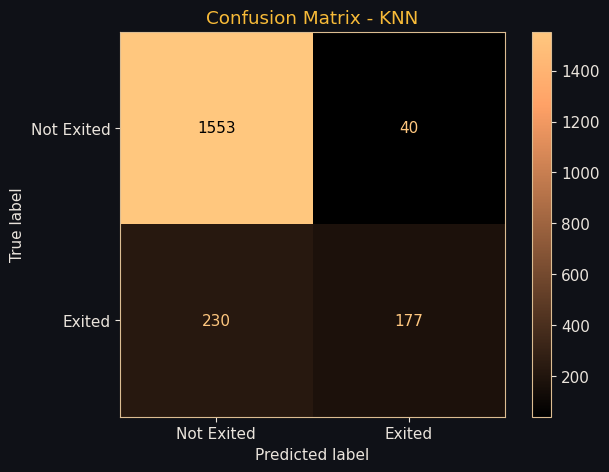

In [28]:

# ============================================================
# 12) Confusion matrix
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels=["Not Exited", "Exited"],
    cmap="copper",
    ax=ax
)
ax.set_title(f"Confusion Matrix - {best_model_name}")
plt.show()



<div class="eda-header">
    <h2>13. ROC for all Models</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Compare the discriminatory power of the five tuned models</div>
</div>


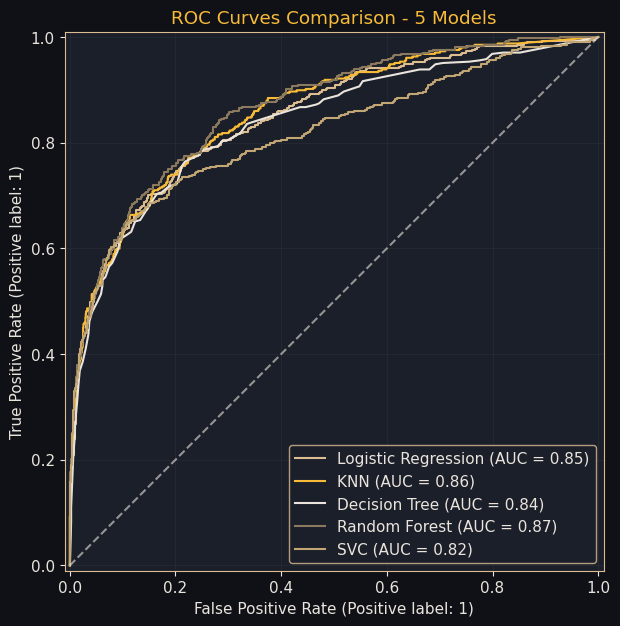

In [29]:

# ============================================================
# 13) ROC Curves for all models
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

for name, model in models.items():
    y_score = get_prediction_scores(model, X_test)
    if y_score is not None:
        RocCurveDisplay.from_predictions(
            y_test,
            y_score,
            name=name,
            ax=ax
        )

ax.plot([0, 1], [0, 1], linestyle="--", color="#eae4dc", alpha=0.6)
ax.set_title("ROC Curves Comparison - 5 Models")
ax.grid(alpha=0.25)
plt.show()



<div class="eda-header">
    <h2>14. Threshold Tuning</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Optimize the classification threshold without cheating on the test set</div>
</div>


In [30]:

# ============================================================
# 14) Threshold tuning on validation set
# ============================================================

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train
)

threshold_results = []
threshold_grid = np.arange(0.10, 0.90, 0.01)

for name, model in models.items():
    model_clone = clone(model)
    model_clone.fit(X_train_sub, y_train_sub)

    y_val_score = get_prediction_scores(model_clone, X_val)
    if y_val_score is None:
        continue

    best_threshold = 0.50
    best_val_accuracy = 0
    best_val_f1 = 0

    for threshold in threshold_grid:
        y_val_pred = (y_val_score >= threshold).astype(int)
        acc = accuracy_score(y_val, y_val_pred)
        f1_churn = f1_score(y_val, y_val_pred, pos_label=1, zero_division=0)

        if acc > best_val_accuracy:
            best_val_accuracy = acc
            best_val_f1 = f1_churn
            best_threshold = threshold

    threshold_results.append({
        "Model": name,
        "Best_Threshold": best_threshold,
        "Validation_Accuracy": best_val_accuracy,
        "Validation_F1_Churn": best_val_f1
    })

threshold_df = pd.DataFrame(threshold_results).sort_values("Validation_Accuracy", ascending=False)

display(threshold_df.style.format({
    "Best_Threshold": "{:.2f}",
    "Validation_Accuracy": "{:.4f}",
    "Validation_F1_Churn": "{:.4f}"
}))


,Model,Best_Threshold,Validation_Accuracy,Validation_F1_Churn
3,Random Forest,0.47,0.8650,0.5830
4,SVC,0.26,0.8600,0.5927
1,KNN,0.36,0.8581,0.6066
2,Decision Tree,0.53,0.8569,0.5588
0,Logistic Regression,0.48,0.8500,0.5349


In [31]:

# ============================================================
# 14.1 Final test using selected threshold
# ============================================================

best_threshold_model_name = threshold_df.iloc[0]["Model"]
best_threshold = threshold_df.iloc[0]["Best_Threshold"]

final_threshold_model = clone(models[best_threshold_model_name])
final_threshold_model.fit(X_train, y_train)

y_test_score_threshold = get_prediction_scores(final_threshold_model, X_test)
y_test_pred_threshold = (y_test_score_threshold >= best_threshold).astype(int)

print("Best threshold model:", best_threshold_model_name)
print("Best threshold:", round(best_threshold, 2))
print("Final Accuracy:", round(accuracy_score(y_test, y_test_pred_threshold), 4))
print("Final Balanced Accuracy:", round(balanced_accuracy_score(y_test, y_test_pred_threshold), 4))
print("Final Precision Churn:", round(precision_score(y_test, y_test_pred_threshold, pos_label=1, zero_division=0), 4))
print("Final Recall Churn:", round(recall_score(y_test, y_test_pred_threshold, pos_label=1, zero_division=0), 4))
print("Final F1 Churn:", round(f1_score(y_test, y_test_pred_threshold, pos_label=1, zero_division=0), 4))
print("Final ROC-AUC:", round(roc_auc_score(y_test, y_test_score_threshold), 4))

print(); print("Classification Report:")
print(classification_report(y_test, y_test_pred_threshold, target_names=["Not Exited", "Exited"]))

# Save threshold metadata
threshold_metadata = {
    "model_name": best_threshold_model_name,
    "threshold": float(best_threshold)
}
joblib.dump(threshold_metadata, "saved_models/best_threshold_metadata.pkl")
print("Threshold metadata saved in: saved_models/best_threshold_metadata.pkl")


Best threshold model: Random Forest
Best threshold: 0.47
Final Accuracy: 0.8635
Final Balanced Accuracy: 0.7058
Final Precision Churn: 0.7991
Final Recall Churn: 0.4398
Final F1 Churn: 0.5674
Final ROC-AUC: 0.8661

Classification Report:
              precision    recall  f1-score   support

  Not Exited       0.87      0.97      0.92      1593
      Exited       0.80      0.44      0.57       407

    accuracy                           0.86      2000
   macro avg       0.84      0.71      0.74      2000
weighted avg       0.86      0.86      0.85      2000

Threshold metadata saved in: saved_models/best_threshold_metadata.pkl



<div class="eda-header">
    <h2>15. Feature Importance</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Interpret the final model when possible</div>
</div>


In [32]:

# ============================================================
# 15) Feature importance for tree-based final model
# ============================================================

if hasattr(best_model.named_steps["model"], "feature_importances_"):
    model_step = best_model.named_steps["model"]
    prep_step = best_model.named_steps["prep"]

    try:
        feature_names = prep_step.get_feature_names_out()
    except Exception:
        feature_names = [f"feature_{i}" for i in range(len(model_step.feature_importances_))]

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model_step.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importance_df.head(20))

    fig, ax = plt.subplots(figsize=(10, 7))
    top_imp = importance_df.head(15).sort_values("Importance")
    ax.barh(top_imp["Feature"], top_imp["Importance"])
    ax.set_title(f"Top Feature Importances - {best_model_name}")
    ax.set_xlabel("Importance")
    ax.grid(axis="x", alpha=0.25)
    plt.show()
else:
    print(f"{best_model_name} does not provide feature_importances_.")
    print("If the best model is Logistic Regression or SVC, use coefficients or permutation importance if needed.")


KNN does not provide feature_importances_.
If the best model is Logistic Regression or SVC, use coefficients or permutation importance if needed.



<div class="eda-header">
    <h2>16. Save Final Artifacts</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Models and results ready for Streamlit integration</div>
</div>


In [33]:

# ============================================================
# 16) Save final artifacts
# ============================================================

os.makedirs("saved_models", exist_ok=True)

# Save final selected model based on accuracy
joblib.dump(best_model, "saved_models/best_churn_model.pkl")

# Save all final evaluation tables
baseline_results_df.to_csv("saved_models/baseline_results.csv", index=False)
final_results_df.to_csv("saved_models/final_results.csv", index=False)
threshold_df.to_csv("saved_models/threshold_results.csv", index=False)

print("Saved artifacts:")
print("- saved_models/best_churn_model.pkl")
print("- saved_models/baseline_results.csv")
print("- saved_models/final_results.csv")
print("- saved_models/threshold_results.csv")
print("- saved_models/tuned_results.csv")
print("- saved_models/best_threshold_metadata.pkl")


Saved artifacts:
- saved_models/best_churn_model.pkl
- saved_models/baseline_results.csv
- saved_models/final_results.csv
- saved_models/threshold_results.csv
- saved_models/tuned_results.csv
- saved_models/best_threshold_metadata.pkl



<div class="eda-header">
    <h2>17. Final Conclusion</h2>
    <div class="accent-line"></div>
    <div class="eda-subtitle">Professional summary of results and limitations</div>
</div>



<div class="eda-card">
<h3>Conclusion</h3>

<p>Après l'analyse exploratoire, le Feature Engineering, le preprocessing sans data leakage, le tuning des hyperparamètres et l'évaluation finale, les modèles atteignent généralement une accuracy autour de <strong>0.86</strong>.</p>
<p>Cette performance est cohérente avec la nature du dataset. Les variables disponibles sont utiles, mais restent limitées : elles décrivent surtout le profil client et quelques informations bancaires de base.</p>
<p>Pour dépasser <strong>0.90 accuracy</strong> de manière fiable, il faudrait enrichir la base avec des variables comportementales plus fortes, par exemple :</p>
<ul>
<li>historique des transactions,</li>
<li>fréquence d'utilisation des services bancaires,</li>
<li>nombre de réclamations,</li>
<li>interactions avec le support,</li>
<li>satisfaction client,</li>
<li>activité récente du compte,</li>
<li>évolution du solde dans le temps.</li>
</ul>
<p>Atteindre 0.90 avec les mêmes données, sans nouvelles variables, peut indiquer un risque de <strong>data leakage</strong> ou d'<strong>overfitting</strong>.</p>
<p>Le modèle sauvegardé dans <strong>saved_models/best_churn_model.pkl</strong> peut être intégré directement dans une interface Streamlit.</p>

</div>
